# 02 Major Index Econometric Benchmarks

This notebook runs the econometric benchmark suite as the baseline reference for the study.

## Forecast Design
- Target: one-step-ahead index level
- Fit period: target dates in `2022`
- Pure-test period: target dates in `2023-01-01` to `2026-03-31`
- Estimation mode: fit once on `2022`, then generate one-step walk-forward forecasts across the logged path

## Benchmark Set
- `LinearRegression`
- `ARMA(0,1)`, `ARMA(1,0)`, `ARMA(1,1)`, `ARMA(1,2)`, `ARMA(2,1)`, `ARMA(2,2)`
- `ARIMA(0,1,0)`, `ARIMA(0,1,1)`, `ARIMA(1,1,0)`, `ARIMA(1,1,1)`, `ARIMA(1,1,2)`, `ARIMA(2,1,1)`, `ARIMA(2,1,2)`
- `ARCH(1)`, `ARCH(2)`, `ARCH(5)`, `ARCH(10)`
- `GARCH(1,1)`, `GARCH(1,2)`, `GARCH(2,1)`, `GARCH(2,2)`
- `GJR-GARCH(1,1)`

## Reporting
- Config-level ranking across indices
- Per-index best-specification tables for context
- Index-level path plots and daily percent-error plots


In [1]:
from __future__ import annotations

import hashlib
import json
import time
import warnings
from contextlib import contextmanager
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from arch import arch_model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA
from tqdm.auto import tqdm


def resolve_project_root() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError("Run this notebook from the project root or its notebooks directory.")


PROJECT_ROOT = resolve_project_root()
PIPELINE_BUNDLE_PATH = PROJECT_ROOT / "outputs" / "01_major_index_sliding_window_pipeline" / "major_index_sliding_window_bundle.joblib"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "02_major_index_econometric_benchmarks"
LOG_DIR = OUTPUT_ROOT / "rolling_logs"
PREDICTIONS_DIR = OUTPUT_ROOT / "predictions"
TABLE_DIR = OUTPUT_ROOT / "tables"
FIG_DIR = OUTPUT_ROOT / "figures"
for directory in [OUTPUT_ROOT, LOG_DIR, PREDICTIONS_DIR, TABLE_DIR, FIG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

TRAIN_END_DATE = "2022-12-31"
EVAL_START_DATE = "2023-01-01"
TARGET_COL = "target_close"
DELTA_COL = "target_delta"
FEATURE_COLS = ["rsi14", "macd_hist", "bb_z20", "roc10", "vol20", "sma10_gap", "atr14_pct", "williams_r14"]
NOTEBOOK_TAG = "02_major_index_econometric_benchmarks"
ALL_LOGS_PATH = OUTPUT_ROOT / "all_prediction_logs.csv"
SCORES_SUMMARY_PATH = TABLE_DIR / "scores_summary.csv"
BEST_CONFIGS_PATH = TABLE_DIR / "best_configs.csv"
INDEX_BEST_CONFIGS_PATH = TABLE_DIR / "index_best_configs.csv"
CONFIG_AVERAGE_RANKING_PATH = TABLE_DIR / "config_average_ranking.csv"
MODEL_SUMMARY_PATH = TABLE_DIR / "model_summary.csv"
TIMING_SUMMARY_PATH = TABLE_DIR / "timing_summary.csv"

TIMING_ROWS: list[dict] = []
FORCE_FRESH_RUN = False
BENCHMARK_SEQUENCE_MODE = "fit_once_walk_forward"
CONFIG_SELECTION_METRIC = "train_close_RMSE"
CONFIG_RANKING_METRIC = "avg_eval_close_RMSE_pct"
EXPORT_PREDICTION_SCOPE = "all_logged"  # all_logged | pure_test_only
PLOT_PREDICTION_SCOPE = "all_logged"  # all_logged | pure_test_only
PLOT_SHADE_PRE_TEST_PERIOD = True
PRE_TEST_LABEL = "Model fit period"
PURE_TEST_LABEL = "Pure test period"
PURE_TEST_START_DATE = EVAL_START_DATE


In [2]:

@contextmanager
def timed_step(step_name: str):
    start = time.perf_counter()
    yield
    elapsed_seconds = time.perf_counter() - start
    TIMING_ROWS.append({"step": step_name, "elapsed_seconds": elapsed_seconds})
    print(f"[TIMER] {step_name}: {elapsed_seconds:.2f}s")


def load_index_frames(path: Path = PIPELINE_BUNDLE_PATH) -> dict[str, pd.DataFrame]:
    bundle = joblib.load(path)["case_bundle"]
    frames: dict[str, pd.DataFrame] = {}
    for case in bundle.values():
        index_key = str(case["index_key"])
        if index_key not in frames:
            frame = case["df"].copy()
            frame["Date"] = pd.to_datetime(frame["Date"], errors="coerce")
            frame["target_date"] = pd.to_datetime(frame["target_date"], errors="coerce")
            frame[DELTA_COL] = pd.to_numeric(frame["target_close"], errors="coerce") - pd.to_numeric(frame["reference_close"], errors="coerce")
            frames[index_key] = frame.sort_values("Date").reset_index(drop=True)
    return frames


def split_train_eval(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_df = frame.loc[frame["target_date"] <= pd.Timestamp(TRAIN_END_DATE)].copy().reset_index(drop=True)
    eval_df = frame.loc[frame["target_date"] >= pd.Timestamp(EVAL_START_DATE)].copy().reset_index(drop=True)
    return train_df, eval_df


LOG_DATE_COLS = ["test_reference_date", "test_target_date"]
SCORE_KEY_COLS = ["index_key", "model", "config_index"]
PREDICTION_KEY_COLS = ["index_key", "model_name", "config_index", "test_target_date"]


def reset_output_targets() -> None:
    for path in [ALL_LOGS_PATH, SCORES_SUMMARY_PATH, BEST_CONFIGS_PATH, INDEX_BEST_CONFIGS_PATH, CONFIG_AVERAGE_RANKING_PATH, MODEL_SUMMARY_PATH, TIMING_SUMMARY_PATH]:
        if path.exists():
            path.unlink()
    for directory in [LOG_DIR, PREDICTIONS_DIR]:
        for csv_path in directory.glob("*.csv"):
            csv_path.unlink()
    for png_path in FIG_DIR.glob("*.png"):
        png_path.unlink()


def append_frame(path: Path, frame: pd.DataFrame) -> None:
    if frame is None or frame.empty:
        return
    frame.to_csv(path, mode="a", header=not path.exists(), index=False)


def load_progress_frame(path: Path, key_cols: list[str] | None = None) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    frame = pd.read_csv(path)
    for col in LOG_DATE_COLS:
        if col in frame.columns:
            frame[col] = pd.to_datetime(frame[col], errors="coerce")
    if key_cols and all(col in frame.columns for col in key_cols):
        frame = frame.drop_duplicates(subset=key_cols, keep="last").reset_index(drop=True)
    return frame


def completed_config_keys(frame: pd.DataFrame) -> set[tuple[str, str, int]]:
    if frame.empty:
        return set()
    return {
        (str(row["index_key"]), str(row["model"]), int(row["config_index"]))
        for _, row in frame.iterrows()
    }


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    yt = np.asarray(y_true, dtype=float)[mask]
    yp = np.asarray(y_pred, dtype=float)[mask]
    if len(yt) == 0:
        return {"MAE": np.nan, "RMSE": np.nan, "R2": np.nan, "n_points": 0}
    return {
        "MAE": float(mean_absolute_error(yt, yp)),
        "RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
        "R2": float(r2_score(yt, yp)) if len(yt) > 1 else np.nan,
        "n_points": int(len(yt)),
    }


def add_error_columns(frame: pd.DataFrame) -> pd.DataFrame:
    if frame is None or len(frame) == 0:
        return frame.copy() if isinstance(frame, pd.DataFrame) else pd.DataFrame()
    enriched = frame.copy()
    enriched["error_points"] = enriched["predicted_close"] - enriched["actual_close"]
    enriched["error_pct"] = np.where(
        np.isfinite(enriched["actual_close"]) & (np.abs(enriched["actual_close"]) > 1e-12),
        100.0 * enriched["error_points"] / enriched["actual_close"],
        np.nan,
    )
    enriched["abs_error_pct"] = np.abs(enriched["error_pct"])
    return enriched


def summarize_config(config: dict) -> str:
    if not config:
        return "default"
    return " ".join(f"{key}={value}" for key, value in config.items())


def config_key(model_name: str, config: dict) -> str:
    payload = json.dumps({"model": model_name, **config}, sort_keys=True)
    return hashlib.sha1(payload.encode("utf-8")).hexdigest()[:16]


def fit_linear_model(train_df: pd.DataFrame, eval_df: pd.DataFrame) -> dict:
    X_train = train_df[FEATURE_COLS].to_numpy(dtype=float)
    y_train = train_df[TARGET_COL].to_numpy(dtype=float)
    X_eval = eval_df[FEATURE_COLS].to_numpy(dtype=float)
    model = LinearRegression()
    fit_start = time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        model.fit(X_train, y_train)
        train_pred = np.asarray(model.predict(X_train), dtype=float).reshape(-1)
        eval_pred = np.asarray(model.predict(X_eval), dtype=float).reshape(-1)
    fit_seconds = time.perf_counter() - fit_start
    return {
        "y_train_pred": train_pred,
        "y_eval_pred": eval_pred,
        "fit_seconds": float(fit_seconds),
        "aic": np.nan,
        "prediction_space": "level",
    }


def fit_arima_model(train_df: pd.DataFrame, eval_df: pd.DataFrame, order: tuple[int, int, int]) -> dict:
    train_series = pd.Series(train_df[TARGET_COL].to_numpy(dtype=float), index=pd.RangeIndex(len(train_df)))
    eval_values = eval_df[TARGET_COL].to_numpy(dtype=float)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit_start = time.perf_counter()
        fitted = ARIMA(train_series, order=order, enforce_stationarity=False, enforce_invertibility=False).fit()
        eval_pred_values = []
        current = fitted
        next_index = len(train_df)
        for observed_value in eval_values:
            next_pred = float(np.asarray(current.forecast(steps=1)).reshape(-1)[0])
            eval_pred_values.append(next_pred)
            current = current.append(pd.Series([observed_value], index=pd.RangeIndex(next_index, next_index + 1)), refit=False)
            next_index += 1
        fit_seconds = time.perf_counter() - fit_start
    train_pred = np.asarray(fitted.fittedvalues, dtype=float).reshape(-1)
    burn_in = max(int(order[0]) + int(order[1]), int(order[2]), 1)
    train_pred[:burn_in] = np.nan
    eval_pred = np.asarray(eval_pred_values, dtype=float)
    return {
        "y_train_pred": train_pred,
        "y_eval_pred": eval_pred,
        "fit_seconds": float(fit_seconds),
        "aic": float(fitted.aic),
        "prediction_space": "level",
    }


def fit_arch_model(train_df: pd.DataFrame, eval_df: pd.DataFrame, model_type: str, p: int, q: int, o: int = 0) -> dict:
    if model_type == "ARCH":
        vol_mode = "ARCH"
        q_value = 0
        o_value = 0
    elif model_type == "GARCH":
        vol_mode = "GARCH"
        q_value = int(q)
        o_value = 0
    elif model_type == "GJR-GARCH":
        vol_mode = "GARCH"
        q_value = int(q)
        o_value = int(o)
    else:
        raise ValueError(model_type)

    train_delta = pd.Series(train_df[DELTA_COL].to_numpy(dtype=float), index=pd.RangeIndex(len(train_df)))
    full_delta = pd.Series(
        pd.concat([train_df[[DELTA_COL]], eval_df[[DELTA_COL]]], axis=0, ignore_index=True)[DELTA_COL].to_numpy(dtype=float),
        index=pd.RangeIndex(len(train_df) + len(eval_df)),
    )

    fit_start = time.perf_counter()
    model_train = arch_model(
        train_delta,
        mean="AR",
        lags=1,
        vol=vol_mode,
        p=int(p),
        o=int(o_value),
        q=int(q_value),
        rescale=False,
    )
    fitted = model_train.fit(disp="off")

    fixed_train = model_train.fix(fitted.params)
    train_forecast = fixed_train.forecast(horizon=1, start=0, align="target", reindex=False)
    train_pred_delta = train_forecast.mean["h.1"].reindex(range(len(train_df))).to_numpy(dtype=float)

    model_full = arch_model(
        full_delta,
        mean="AR",
        lags=1,
        vol=vol_mode,
        p=int(p),
        o=int(o_value),
        q=int(q_value),
        rescale=False,
    )
    fixed_full = model_full.fix(fitted.params)
    eval_forecast = fixed_full.forecast(horizon=1, start=len(train_df) - 1, align="target", reindex=False)
    eval_pred_delta = eval_forecast.mean["h.1"].reindex(range(len(train_df), len(train_df) + len(eval_df))).to_numpy(dtype=float)
    fit_seconds = time.perf_counter() - fit_start

    train_pred = train_df["reference_close"].to_numpy(dtype=float) + train_pred_delta
    eval_pred = eval_df["reference_close"].to_numpy(dtype=float) + eval_pred_delta
    return {
        "y_train_pred": train_pred,
        "y_eval_pred": eval_pred,
        "fit_seconds": float(fit_seconds),
        "aic": float(fitted.aic),
        "prediction_space": "level",
    }


def project_predictions(frame: pd.DataFrame, y_pred: np.ndarray, prediction_space: str = "level") -> dict[str, np.ndarray]:
    if prediction_space != "level":
        raise ValueError(prediction_space)
    actual_close = frame["target_close"].to_numpy(dtype=float)
    predicted_close = np.asarray(y_pred, dtype=float).reshape(-1)
    return {
        "actual_close": actual_close,
        "predicted_close": predicted_close,
    }


def build_prediction_rows(
    *,
    index_key: str,
    model_name: str,
    config_index: int,
    config_key_value: str,
    config_summary: str,
    config_json: str,
    eval_df: pd.DataFrame,
    eval_pred: np.ndarray,
    fit_seconds: float,
    prediction_space: str,
) -> list[dict]:
    rows = []
    projection = project_predictions(eval_df, eval_pred, prediction_space)
    for i, (_, row) in enumerate(eval_df.iterrows()):
        actual_close = float(projection["actual_close"][i]) if np.isfinite(projection["actual_close"][i]) else np.nan
        predicted_close = float(projection["predicted_close"][i]) if np.isfinite(projection["predicted_close"][i]) else np.nan
        rows.append(
            {
                "index_key": index_key,
                "model_name": model_name,
                "config_index": int(config_index),
                "config_key": config_key_value,
                "config_summary": config_summary,
                "config_json": config_json,
                "prediction_space": prediction_space,
                "test_reference_date": pd.Timestamp(row["Date"]),
                "test_target_date": pd.Timestamp(row["target_date"]),
                "reference_close": float(row["reference_close"]),
                "target_close": float(row["target_close"]),
                "y_true": actual_close,
                "y_pred": predicted_close,
                "actual_close": actual_close,
                "predicted_close": predicted_close,
                "fit_seconds": float(fit_seconds),
            }
        )
    return add_error_columns(pd.DataFrame(rows)).to_dict("records")


def benchmark_label(model_name: str, config_summary: str) -> str:
    if not config_summary or config_summary == "default":
        return model_name
    return f"{model_name} | {config_summary}"


def enrich_scores_with_relative_metrics(scores: pd.DataFrame, prediction_log: pd.DataFrame) -> pd.DataFrame:
    if scores.empty or prediction_log.empty:
        return scores.copy()
    pure_test = prediction_log.loc[prediction_log["analysis_partition"].eq("pure_test")].copy()
    fit_period = prediction_log.loc[prediction_log["analysis_partition"].eq("fit_period")].copy()

    eval_mean = pure_test.groupby("index_key", as_index=False)["actual_close"].mean().rename(columns={"actual_close": "eval_mean_close"})
    train_mean = fit_period.groupby("index_key", as_index=False)["actual_close"].mean().rename(columns={"actual_close": "train_mean_close"})

    enriched = scores.merge(train_mean, on="index_key", how="left").merge(eval_mean, on="index_key", how="left")
    enriched["benchmark_label"] = enriched.apply(lambda row: benchmark_label(str(row["model"]), str(row["config_summary"])), axis=1)
    enriched["train_close_RMSE_pct"] = 100.0 * enriched["train_close_RMSE"] / enriched["train_mean_close"]
    enriched["train_close_MAE_pct"] = 100.0 * enriched["train_close_MAE"] / enriched["train_mean_close"]
    enriched["eval_close_RMSE_pct"] = 100.0 * enriched["eval_close_RMSE"] / enriched["eval_mean_close"]
    enriched["eval_close_MAE_pct"] = 100.0 * enriched["eval_close_MAE"] / enriched["eval_mean_close"]
    return enriched


def build_config_average_ranking(scores: pd.DataFrame) -> pd.DataFrame:
    if scores.empty:
        return pd.DataFrame()
    grouped = (
        scores.groupby(
            ["model", "config_index", "config_key", "config_summary", "prediction_space", "benchmark_label"],
            as_index=False,
            dropna=False,
        )
        .agg(
            index_count=("index_key", "nunique"),
            avg_selection_metric=("selection_metric", "mean"),
            avg_train_close_RMSE=("train_close_RMSE", "mean"),
            avg_train_close_RMSE_pct=("train_close_RMSE_pct", "mean"),
            avg_train_abs_error_pct_mean=("train_abs_error_pct_mean", "mean"),
            avg_eval_close_RMSE=("eval_close_RMSE", "mean"),
            avg_eval_close_RMSE_pct=("eval_close_RMSE_pct", "mean"),
            avg_eval_close_MAE=("eval_close_MAE", "mean"),
            avg_eval_close_MAE_pct=("eval_close_MAE_pct", "mean"),
            avg_eval_abs_error_pct_mean=("eval_abs_error_pct_mean", "mean"),
            avg_eval_error_pct_bias=("eval_error_pct_bias", "mean"),
            avg_eval_close_R2=("eval_close_R2", "mean"),
            avg_fit_seconds=("mean_fit_seconds", "mean"),
        )
        .sort_values(
            ["avg_eval_close_RMSE_pct", "avg_eval_abs_error_pct_mean", "avg_eval_close_MAE_pct", "model", "config_index"],
            ascending=[True, True, True, True, True],
            kind="stable",
        )
        .reset_index(drop=True)
    )
    return grouped


def select_best_family_configs(scores: pd.DataFrame) -> pd.DataFrame:
    picks = []
    for (index_key, model_name), group in scores.groupby(["index_key", "model"], as_index=False):
        valid = group.dropna(subset=["selection_metric"]).copy()
        if valid.empty:
            continue
        pick = valid.sort_values(
            ["selection_metric", "eval_close_RMSE_pct", "eval_abs_error_pct_mean", "eval_close_MAE_pct", "config_index"],
            ascending=[True, True, True, True, True],
            kind="stable",
        ).iloc[0]
        picks.append(pick.to_dict())
    picked = pd.DataFrame(picks)
    if picked.empty:
        return picked
    return picked.sort_values(["index_key", "model"]).reset_index(drop=True)


def select_best_index_configs(scores: pd.DataFrame) -> pd.DataFrame:
    picks = []
    for index_key, group in scores.groupby("index_key", as_index=False):
        valid = group.dropna(subset=["eval_close_RMSE_pct"]).copy()
        if valid.empty:
            continue
        pick = valid.sort_values(
            ["eval_close_RMSE_pct", "eval_abs_error_pct_mean", "eval_close_MAE_pct", "model", "config_index"],
            ascending=[True, True, True, True, True],
            kind="stable",
        ).iloc[0]
        picks.append(pick.to_dict())
    picked = pd.DataFrame(picks)
    if picked.empty:
        return picked
    return picked.sort_values(["index_key"]).reset_index(drop=True)


def select_best_configs(scores: pd.DataFrame) -> pd.DataFrame:
    return select_best_family_configs(scores)


In [3]:
BENCHMARK_CONFIGS: dict[str, list[dict]] = {
    "LinearRegression": [{}],
    "ARMA": [
        {"order": (0, 0, 1)},
        {"order": (1, 0, 0)},
        {"order": (1, 0, 1)},
        {"order": (1, 0, 2)},
        {"order": (2, 0, 1)},
        {"order": (2, 0, 2)},
    ],
    "ARIMA": [
        {"order": (0, 1, 0)},
        {"order": (0, 1, 1)},
        {"order": (1, 1, 0)},
        {"order": (1, 1, 1)},
        {"order": (1, 1, 2)},
        {"order": (2, 1, 1)},
        {"order": (2, 1, 2)},
    ],
    "ARCH": [{"p": 1, "q": 0}, {"p": 2, "q": 0}, {"p": 5, "q": 0}, {"p": 10, "q": 0}],
    "GARCH": [{"p": 1, "q": 1}, {"p": 1, "q": 2}, {"p": 2, "q": 1}, {"p": 2, "q": 2}],
    "GJR-GARCH": [{"p": 1, "o": 1, "q": 1}],
}


with timed_step("fit_chronological_benchmarks"):
    index_frames = load_index_frames()
    if FORCE_FRESH_RUN:
        reset_output_targets()

    existing_scores = load_progress_frame(SCORES_SUMMARY_PATH, key_cols=SCORE_KEY_COLS)
    completed_configs = completed_config_keys(existing_scores)
    total_configs_full = sum(len(configs) for configs in BENCHMARK_CONFIGS.values()) * len(index_frames)
    completed_config_count = min(len(completed_configs), total_configs_full)

    with tqdm(total=total_configs_full, initial=completed_config_count, desc="Benchmark fits") as progress_bar:
        for index_key, frame in index_frames.items():
            train_df, eval_df = split_train_eval(frame)

            for model_name, configs in BENCHMARK_CONFIGS.items():
                for config_index, config in enumerate(configs, start=1):
                    config_tuple = (index_key, model_name, int(config_index))
                    if config_tuple in completed_configs:
                        continue

                    progress_bar.set_postfix_str(f"{index_key} | {model_name}", refresh=False)
                    cfg_key = config_key(model_name, config)
                    cfg_summary = summarize_config(config)
                    cfg_json = json.dumps(config, sort_keys=True)

                    if model_name == "LinearRegression":
                        result = fit_linear_model(train_df, eval_df)
                    elif model_name in {"ARMA", "ARIMA"}:
                        result = fit_arima_model(train_df, eval_df, order=tuple(config["order"]))
                    elif model_name in {"ARCH", "GARCH", "GJR-GARCH"}:
                        result = fit_arch_model(
                            train_df,
                            eval_df,
                            model_type=model_name,
                            p=int(config["p"]),
                            q=int(config["q"]),
                            o=int(config.get("o", 0)),
                        )
                    else:
                        raise ValueError(model_name)

                    y_train_pred = np.asarray(result["y_train_pred"], dtype=float).reshape(-1)
                    y_eval_pred = np.asarray(result["y_eval_pred"], dtype=float).reshape(-1)
                    fit_seconds = float(result["fit_seconds"])
                    aic = float(result.get("aic", np.nan))
                    prediction_space = str(result.get("prediction_space", "level"))

                    train_prediction_frame = pd.DataFrame(
                        build_prediction_rows(
                            index_key=index_key,
                            model_name=model_name,
                            config_index=int(config_index),
                            config_key_value=cfg_key,
                            config_summary=cfg_summary,
                            config_json=cfg_json,
                            eval_df=train_df,
                            eval_pred=y_train_pred,
                            fit_seconds=fit_seconds,
                            prediction_space=prediction_space,
                        )
                    )
                    if not train_prediction_frame.empty:
                        train_prediction_frame["analysis_partition"] = "fit_period"
                        train_prediction_frame["analysis_scope"] = "model_fit_period"

                    eval_prediction_frame = pd.DataFrame(
                        build_prediction_rows(
                            index_key=index_key,
                            model_name=model_name,
                            config_index=int(config_index),
                            config_key_value=cfg_key,
                            config_summary=cfg_summary,
                            config_json=cfg_json,
                            eval_df=eval_df,
                            eval_pred=y_eval_pred,
                            fit_seconds=fit_seconds,
                            prediction_space=prediction_space,
                        )
                    )
                    if not eval_prediction_frame.empty:
                        eval_prediction_frame["analysis_partition"] = "pure_test"
                        eval_prediction_frame["analysis_scope"] = "held_out_pure_test"

                    prediction_frame = add_error_columns(pd.concat([train_prediction_frame, eval_prediction_frame], ignore_index=True))
                    train_prediction_frame = prediction_frame.loc[prediction_frame["analysis_partition"].eq("fit_period")].copy()
                    eval_prediction_frame = prediction_frame.loc[prediction_frame["analysis_partition"].eq("pure_test")].copy()

                    train_close_metrics = regression_metrics(train_prediction_frame["actual_close"], train_prediction_frame["predicted_close"])
                    eval_close_metrics = regression_metrics(eval_prediction_frame["actual_close"], eval_prediction_frame["predicted_close"])

                    score_frame = pd.DataFrame(
                        [
                            {
                                "index_key": index_key,
                                "model": model_name,
                                "config_index": int(config_index),
                                "config_key": cfg_key,
                                "config_summary": cfg_summary,
                                "config_json": cfg_json,
                                "prediction_space": "level",
                                "status": "completed",
                                "error_message": "",
                                "selection_metric_name": CONFIG_SELECTION_METRIC,
                                "selection_metric": train_close_metrics["RMSE"],
                                "AIC": aic,
                                "train_close_MAE": train_close_metrics["MAE"],
                                "train_close_RMSE": train_close_metrics["RMSE"],
                                "train_close_R2": train_close_metrics["R2"],
                                "train_close_n": train_close_metrics["n_points"],
                                "train_abs_error_pct_mean": float(train_prediction_frame["abs_error_pct"].mean()) if not train_prediction_frame.empty else np.nan,
                                "train_error_pct_bias": float(train_prediction_frame["error_pct"].mean()) if not train_prediction_frame.empty else np.nan,
                                "eval_close_MAE": eval_close_metrics["MAE"],
                                "eval_close_RMSE": eval_close_metrics["RMSE"],
                                "eval_close_R2": eval_close_metrics["R2"],
                                "eval_close_n": eval_close_metrics["n_points"],
                                "eval_abs_error_pct_mean": float(eval_prediction_frame["abs_error_pct"].mean()) if not eval_prediction_frame.empty else np.nan,
                                "eval_error_pct_bias": float(eval_prediction_frame["error_pct"].mean()) if not eval_prediction_frame.empty else np.nan,
                                "mean_fit_seconds": fit_seconds,
                                "fit_mode": BENCHMARK_SEQUENCE_MODE,
                                "target_definition": "one_step_index_level",
                            }
                        ]
                    )

                    append_frame(ALL_LOGS_PATH, prediction_frame)
                    append_frame(SCORES_SUMMARY_PATH, score_frame)
                    completed_configs.add(config_tuple)
                    progress_bar.update(1)

    scores_summary = load_progress_frame(SCORES_SUMMARY_PATH, key_cols=SCORE_KEY_COLS)
    prediction_log = load_progress_frame(ALL_LOGS_PATH, key_cols=PREDICTION_KEY_COLS)
    if not scores_summary.empty:
        scores_summary = scores_summary.sort_values(["index_key", "model", "config_index"]).reset_index(drop=True)
        scores_summary.to_csv(SCORES_SUMMARY_PATH, index=False)
    if not prediction_log.empty:
        prediction_log = add_error_columns(prediction_log.sort_values(["index_key", "model_name", "config_index", "test_target_date"]).reset_index(drop=True))
        prediction_log.to_csv(ALL_LOGS_PATH, index=False)
        for (index_key, model_name), group in prediction_log.groupby(["index_key", "model_name"], as_index=False):
            group.to_csv(LOG_DIR / f"{index_key}_{model_name}.csv", index=False)

display(scores_summary.head(20))


Benchmark fits:   0%|          | 0/92 [00:00<?, ?it/s]

[TIMER] fit_chronological_benchmarks: 106.92s


,index_key,model,config_index,config_key,config_summary,config_json,prediction_space,status,error_message,selection_metric_name,...,train_error_pct_bias,eval_close_MAE,eval_close_RMSE,eval_close_R2,eval_close_n,eval_abs_error_pct_mean,eval_error_pct_bias,mean_fit_seconds,fit_mode,target_definition
0,DOWJONES,ARCH,1,91b524aa4f66e8c9,p=1 q=0,"{""p"": 1, ""q"": 0}",level,completed,NaN,train_close_RMSE,...,0.006508,245.128813,344.448039,0.995307,813,0.607982,-0.064852,0.005199,fit_once_walk_forward,one_step_index_level
1,DOWJONES,ARCH,2,2cf64ba7fd7d5882,p=2 q=0,"{""p"": 2, ""q"": 0}",level,completed,NaN,train_close_RMSE,...,0.006506,245.128909,344.448096,0.995307,813,0.607982,-0.064854,0.003969,fit_once_walk_forward,one_step_index_level
2,DOWJONES,ARCH,3,6ab4cb603b89f6c3,p=5 q=0,"{""p"": 5, ""q"": 0}",level,completed,NaN,train_close_RMSE,...,-0.003393,245.530567,344.709651,0.995300,813,0.608977,-0.072756,0.009815,fit_once_walk_forward,one_step_index_level
3,DOWJONES,ARCH,4,fa9071f0b10edd13,p=10 q=0,"{""p"": 10, ""q"": 0}",level,completed,NaN,train_close_RMSE,...,0.009995,245.006265,344.356780,0.995310,813,0.607626,-0.061396,0.024266,fit_once_walk_forward,one_step_index_level
4,DOWJONES,ARIMA,1,c10e68784e86e399,"order=(0, 1, 0)","{""order"": [0, 1, 0]}",level,completed,NaN,train_close_RMSE,...,0.039761,243.981535,343.770920,0.995326,813,0.605147,-0.037624,1.677810,fit_once_walk_forward,one_step_index_level
5,DOWJONES,ARIMA,2,d28e287954183cc2,"order=(0, 1, 1)","{""order"": [0, 1, 1]}",level,completed,NaN,train_close_RMSE,...,0.039552,243.994850,343.769749,0.995326,813,0.605141,-0.037409,1.841554,fit_once_walk_forward,one_step_index_level
6,DOWJONES,ARIMA,3,e08a1780a457d1e6,"order=(1, 1, 0)","{""order"": [1, 1, 0]}",level,completed,NaN,train_close_RMSE,...,0.033234,243.992634,343.769117,0.995326,813,0.605138,-0.037424,1.698031,fit_once_walk_forward,one_step_index_level
7,DOWJONES,ARIMA,4,03d5e910984fb29b,"order=(1, 1, 1)","{""order"": [1, 1, 1]}",level,completed,NaN,train_close_RMSE,...,0.041330,244.265905,343.756827,0.995326,813,0.605983,-0.038823,1.847844,fit_once_walk_forward,one_step_index_level
8,DOWJONES,ARIMA,5,e5dbc971a5fcd942,"order=(1, 1, 2)","{""order"": [1, 1, 2]}",level,completed,NaN,train_close_RMSE,...,0.036937,245.089510,344.180507,0.995314,813,0.608028,-0.040174,1.848269,fit_once_walk_forward,one_step_index_level
9,DOWJONES,ARIMA,6,28a0f526983d0240,"order=(2, 1, 1)","{""order"": [2, 1, 1]}",level,completed,NaN,train_close_RMSE,...,0.036179,244.597120,343.510861,0.995333,813,0.606832,-0.040025,1.829055,fit_once_walk_forward,one_step_index_level


In [4]:
with timed_step("select_and_export_benchmark_summaries"):
    scores_summary = enrich_scores_with_relative_metrics(scores_summary, prediction_log)
    config_average_ranking = build_config_average_ranking(scores_summary)
    index_best_configs = select_best_index_configs(scores_summary)
    best_configs = select_best_family_configs(scores_summary)

    prediction_rows = []
    for _, best_row in best_configs.iterrows():
        subset = prediction_log.loc[
            prediction_log["index_key"].eq(best_row["index_key"])
            & prediction_log["model_name"].eq(best_row["model"])
            & prediction_log["config_key"].eq(best_row["config_key"])
        ].copy()
        if EXPORT_PREDICTION_SCOPE == "pure_test_only":
            subset = subset.loc[subset["analysis_partition"].eq("pure_test")].copy()
        elif EXPORT_PREDICTION_SCOPE != "all_logged":
            raise ValueError(EXPORT_PREDICTION_SCOPE)

        subset = add_error_columns(subset)
        subset["benchmark_label"] = benchmark_label(str(best_row["model"]), str(best_row["config_summary"]))
        prediction_path = PREDICTIONS_DIR / f"{best_row['index_key']}_{best_row['model']}_{best_row['config_key']}.csv"
        subset.to_csv(prediction_path, index=False)
        row = dict(best_row)
        row["prediction_path"] = str(prediction_path)
        row["prediction_export_scope"] = EXPORT_PREDICTION_SCOPE
        prediction_rows.append(row)

    model_summary = pd.DataFrame(prediction_rows)
    if not model_summary.empty:
        model_summary = model_summary.sort_values(
            ["index_key", "eval_close_RMSE_pct", "eval_abs_error_pct_mean", "eval_close_MAE_pct", "mean_fit_seconds"],
            ascending=[True, True, True, True, True],
        ).reset_index(drop=True)

    scores_summary.to_csv(SCORES_SUMMARY_PATH, index=False)
    config_average_ranking.to_csv(CONFIG_AVERAGE_RANKING_PATH, index=False)
    index_best_configs.to_csv(INDEX_BEST_CONFIGS_PATH, index=False)
    best_configs.to_csv(BEST_CONFIGS_PATH, index=False)
    model_summary.to_csv(MODEL_SUMMARY_PATH, index=False)

timing_summary = pd.DataFrame(TIMING_ROWS).sort_values("elapsed_seconds", ascending=False).reset_index(drop=True)
timing_summary.to_csv(TIMING_SUMMARY_PATH, index=False)

print("Top config-level ranking across indices")
display(config_average_ranking.head(20))
print("Best overall config by index")
display(index_best_configs)
print("Best family config by index")
display(best_configs)
print("Model summary")
display(model_summary)
print("Timing summary")
display(timing_summary)

[TIMER] select_and_export_benchmark_summaries: 0.38s
Top config-level ranking across indices


,model,config_index,config_key,config_summary,prediction_space,benchmark_label,index_count,avg_selection_metric,avg_train_close_RMSE,avg_train_close_RMSE_pct,avg_train_abs_error_pct_mean,avg_eval_close_RMSE,avg_eval_close_RMSE_pct,avg_eval_close_MAE,avg_eval_close_MAE_pct,avg_eval_abs_error_pct_mean,avg_eval_error_pct_bias,avg_eval_close_R2,avg_fit_seconds
0,ARIMA,4,03d5e910984fb29b,"order=(1, 1, 1)",level,"ARIMA | order=(1, 1, 1)",4,189.534871,189.534871,1.603794,1.274107,160.620668,1.002769,114.148154,0.708326,0.714455,-0.063878,0.996385,1.846739
1,ARIMA,3,e08a1780a457d1e6,"order=(1, 1, 0)",level,"ARIMA | order=(1, 1, 0)",4,189.223429,189.223429,1.600924,1.270912,160.692888,1.003410,113.916041,0.706863,0.712931,-0.060020,0.996381,1.702085
2,ARIMA,2,d28e287954183cc2,"order=(0, 1, 1)",level,"ARIMA | order=(0, 1, 1)",4,189.994621,189.994621,1.609344,1.276538,160.710026,1.003570,113.908122,0.706800,0.712844,-0.059800,0.996380,1.826392
3,ARIMA,1,c10e68784e86e399,"order=(0, 1, 0)",level,"ARIMA | order=(0, 1, 0)",4,190.006129,190.006129,1.609439,1.276192,160.758163,1.003771,113.890904,0.706728,0.712764,-0.059615,0.996379,1.675528
4,ARIMA,5,e5dbc971a5fcd942,"order=(1, 1, 2)",level,"ARIMA | order=(1, 1, 2)",4,189.102118,189.102118,1.600499,1.268447,160.922048,1.004983,114.555700,0.711560,0.717476,-0.067005,0.996370,1.841716
5,ARIMA,6,28a0f526983d0240,"order=(2, 1, 1)",level,"ARIMA | order=(2, 1, 1)",4,189.214699,189.214699,1.599815,1.267828,160.861159,1.005714,114.411373,0.711154,0.717015,-0.064812,0.996367,1.872972
6,GARCH,3,0a3562dbd0248afa,p=2 q=1,level,GARCH | p=2 q=1,4,189.755729,189.755729,1.606776,1.268854,161.323853,1.008291,115.051802,0.715542,0.721710,-0.116571,0.996349,0.007367
7,GARCH,4,510d001324f1d615,p=2 q=2,level,GARCH | p=2 q=2,4,189.754712,189.754712,1.606767,1.268814,161.341846,1.008397,115.085382,0.715739,0.721914,-0.117447,0.996349,0.011209
8,GARCH,1,c233a1992db9852e,p=1 q=1,level,GARCH | p=1 q=1,4,189.753477,189.753477,1.606743,1.268742,161.363459,1.008523,115.133721,0.716161,0.722356,-0.119774,0.996348,0.006139
9,GARCH,2,f5f01a0430640286,p=1 q=2,level,GARCH | p=1 q=2,4,189.753119,189.753119,1.606740,1.268683,161.376385,1.008596,115.147278,0.716237,0.722431,-0.120211,0.996347,0.009952


Best overall config by index


,index_key,model,config_index,config_key,config_summary,config_json,prediction_space,status,error_message,selection_metric_name,...,mean_fit_seconds,fit_mode,target_definition,train_mean_close,eval_mean_close,benchmark_label,train_close_RMSE_pct,train_close_MAE_pct,eval_close_RMSE_pct,eval_close_MAE_pct
0,DOWJONES,ARIMA,6,28a0f526983d0240,"order=(2, 1, 1)","{""order"": [2, 1, 1]}",level,completed,NaN,train_close_RMSE,...,1.829055,fit_once_walk_forward,one_step_index_level,32663.936974,40247.973759,"ARIMA | order=(2, 1, 1)",1.271215,0.981470,0.853486,0.607725
1,NASDAQ,ARIMA,4,03d5e910984fb29b,"order=(1, 1, 1)","{""order"": [1, 1, 1]}",level,completed,NaN,train_close_RMSE,...,1.858457,fit_once_walk_forward,one_step_index_level,12022.151877,17351.357069,"ARIMA | order=(1, 1, 1)",2.024677,1.625231,1.256326,0.898958
2,RUSSELL3000,ARIMA,4,03d5e910984fb29b,"order=(1, 1, 1)","{""order"": [1, 1, 1]}",level,completed,NaN,train_close_RMSE,...,1.871702,fit_once_walk_forward,one_step_index_level,2349.032824,3096.962397,"ARIMA | order=(1, 1, 1)",1.580044,1.251799,0.960333,0.672520
3,SP500,ARIMA,4,03d5e910984fb29b,"order=(1, 1, 1)","{""order"": [1, 1, 1]}",level,completed,NaN,train_close_RMSE,...,1.808954,fit_once_walk_forward,one_step_index_level,4055.236315,5423.156196,"ARIMA | order=(1, 1, 1)",1.539360,1.214727,0.940320,0.654925


Best family config by index


,index_key,model,config_index,config_key,config_summary,config_json,prediction_space,status,error_message,selection_metric_name,...,mean_fit_seconds,fit_mode,target_definition,train_mean_close,eval_mean_close,benchmark_label,train_close_RMSE_pct,train_close_MAE_pct,eval_close_RMSE_pct,eval_close_MAE_pct
0,DOWJONES,ARCH,2,2cf64ba7fd7d5882,p=2 q=0,"{""p"": 2, ""q"": 0}",level,completed,NaN,train_close_RMSE,...,0.003969,fit_once_walk_forward,one_step_index_level,32663.936974,40247.973759,ARCH | p=2 q=0,1.270987,0.979436,0.855815,0.609047
1,DOWJONES,ARIMA,7,3b5a93ce65c2f2fb,"order=(2, 1, 2)","{""order"": [2, 1, 2]}",level,completed,NaN,train_close_RMSE,...,1.818232,fit_once_walk_forward,one_step_index_level,32663.936974,40247.973759,"ARIMA | order=(2, 1, 2)",1.266325,0.978618,0.856304,0.608699
2,DOWJONES,ARMA,4,36f8102a6e7a094b,"order=(1, 0, 2)","{""order"": [1, 0, 2]}",level,completed,NaN,train_close_RMSE,...,2.243558,fit_once_walk_forward,one_step_index_level,32663.936974,40247.973759,"ARMA | order=(1, 0, 2)",1.254139,0.982054,1.242709,0.977410
3,DOWJONES,GARCH,2,f5f01a0430640286,p=1 q=2,"{""p"": 1, ""q"": 2}",level,completed,NaN,train_close_RMSE,...,0.006884,fit_once_walk_forward,one_step_index_level,32663.936974,40247.973759,GARCH | p=1 q=2,1.270987,0.979432,0.855820,0.609055
4,DOWJONES,GJR-GARCH,1,11aa4f92f6b0f44e,p=1 o=1 q=1,"{""o"": 1, ""p"": 1, ""q"": 1}",level,completed,NaN,train_close_RMSE,...,0.007484,fit_once_walk_forward,one_step_index_level,32663.936974,40247.973759,GJR-GARCH | p=1 o=1 q=1,1.271025,0.979648,0.855320,0.608272
5,DOWJONES,LinearRegression,1,868ed884d1c61ab9,default,{},level,completed,NaN,train_close_RMSE,...,0.000399,fit_once_walk_forward,one_step_index_level,32663.936974,40247.973759,LinearRegression,3.215371,2.628005,20.102728,15.958986
6,NASDAQ,ARCH,1,91b524aa4f66e8c9,p=1 q=0,"{""p"": 1, ""q"": 0}",level,completed,NaN,train_close_RMSE,...,0.006246,fit_once_walk_forward,one_step_index_level,12022.151877,17351.357069,ARCH | p=1 q=0,2.030701,1.620808,1.267943,0.915192
7,NASDAQ,ARIMA,7,3b5a93ce65c2f2fb,"order=(2, 1, 2)","{""order"": [2, 1, 2]}",level,completed,NaN,train_close_RMSE,...,1.901625,fit_once_walk_forward,one_step_index_level,12022.151877,17351.357069,"ARIMA | order=(2, 1, 2)",1.987486,1.595100,1.283880,0.920692
8,NASDAQ,ARMA,4,36f8102a6e7a094b,"order=(1, 0, 2)","{""order"": [1, 0, 2]}",level,completed,NaN,train_close_RMSE,...,2.235920,fit_once_walk_forward,one_step_index_level,12022.151877,17351.357069,"ARMA | order=(1, 0, 2)",2.004158,1.612315,1.573024,1.230098
9,NASDAQ,GARCH,2,f5f01a0430640286,p=1 q=2,"{""p"": 1, ""q"": 2}",level,completed,NaN,train_close_RMSE,...,0.017112,fit_once_walk_forward,one_step_index_level,12022.151877,17351.357069,GARCH | p=1 q=2,2.030722,1.620659,1.267060,0.913241


Model summary


,index_key,model,config_index,config_key,config_summary,config_json,prediction_space,status,error_message,selection_metric_name,...,target_definition,train_mean_close,eval_mean_close,benchmark_label,train_close_RMSE_pct,train_close_MAE_pct,eval_close_RMSE_pct,eval_close_MAE_pct,prediction_path,prediction_export_scope
0,DOWJONES,GJR-GARCH,1,11aa4f92f6b0f44e,p=1 o=1 q=1,"{""o"": 1, ""p"": 1, ""q"": 1}",level,completed,NaN,train_close_RMSE,...,one_step_index_level,32663.936974,40247.973759,GJR-GARCH | p=1 o=1 q=1,1.271025,0.979648,0.855320,0.608272,/Users/jimyhc/Desktop/research/quantum_index/r...,all_logged
1,DOWJONES,ARCH,2,2cf64ba7fd7d5882,p=2 q=0,"{""p"": 2, ""q"": 0}",level,completed,NaN,train_close_RMSE,...,one_step_index_level,32663.936974,40247.973759,ARCH | p=2 q=0,1.270987,0.979436,0.855815,0.609047,/Users/jimyhc/Desktop/research/quantum_index/r...,all_logged
2,DOWJONES,GARCH,2,f5f01a0430640286,p=1 q=2,"{""p"": 1, ""q"": 2}",level,completed,NaN,train_close_RMSE,...,one_step_index_level,32663.936974,40247.973759,GARCH | p=1 q=2,1.270987,0.979432,0.855820,0.609055,/Users/jimyhc/Desktop/research/quantum_index/r...,all_logged
3,DOWJONES,ARIMA,7,3b5a93ce65c2f2fb,"order=(2, 1, 2)","{""order"": [2, 1, 2]}",level,completed,NaN,train_close_RMSE,...,one_step_index_level,32663.936974,40247.973759,"ARIMA | order=(2, 1, 2)",1.266325,0.978618,0.856304,0.608699,/Users/jimyhc/Desktop/research/quantum_index/r...,all_logged
4,DOWJONES,ARMA,4,36f8102a6e7a094b,"order=(1, 0, 2)","{""order"": [1, 0, 2]}",level,completed,NaN,train_close_RMSE,...,one_step_index_level,32663.936974,40247.973759,"ARMA | order=(1, 0, 2)",1.254139,0.982054,1.242709,0.977410,/Users/jimyhc/Desktop/research/quantum_index/r...,all_logged
5,DOWJONES,LinearRegression,1,868ed884d1c61ab9,default,{},level,completed,NaN,train_close_RMSE,...,one_step_index_level,32663.936974,40247.973759,LinearRegression,3.215371,2.628005,20.102728,15.958986,/Users/jimyhc/Desktop/research/quantum_index/r...,all_logged
6,NASDAQ,GARCH,2,f5f01a0430640286,p=1 q=2,"{""p"": 1, ""q"": 2}",level,completed,NaN,train_close_RMSE,...,one_step_index_level,12022.151877,17351.357069,GARCH | p=1 q=2,2.030722,1.620659,1.267060,0.913241,/Users/jimyhc/Desktop/research/quantum_index/r...,all_logged
7,NASDAQ,ARCH,1,91b524aa4f66e8c9,p=1 q=0,"{""p"": 1, ""q"": 0}",level,completed,NaN,train_close_RMSE,...,one_step_index_level,12022.151877,17351.357069,ARCH | p=1 q=0,2.030701,1.620808,1.267943,0.915192,/Users/jimyhc/Desktop/research/quantum_index/r...,all_logged
8,NASDAQ,GJR-GARCH,1,11aa4f92f6b0f44e,p=1 o=1 q=1,"{""o"": 1, ""p"": 1, ""q"": 1}",level,completed,NaN,train_close_RMSE,...,one_step_index_level,12022.151877,17351.357069,GJR-GARCH | p=1 o=1 q=1,2.030697,1.620310,1.268420,0.915458,/Users/jimyhc/Desktop/research/quantum_index/r...,all_logged
9,NASDAQ,ARIMA,7,3b5a93ce65c2f2fb,"order=(2, 1, 2)","{""order"": [2, 1, 2]}",level,completed,NaN,train_close_RMSE,...,one_step_index_level,12022.151877,17351.357069,"ARIMA | order=(2, 1, 2)",1.987486,1.595100,1.283880,0.920692,/Users/jimyhc/Desktop/research/quantum_index/r...,all_logged


Timing summary


,step,elapsed_seconds
0,fit_chronological_benchmarks,106.917241
1,select_and_export_benchmark_summaries,0.384465


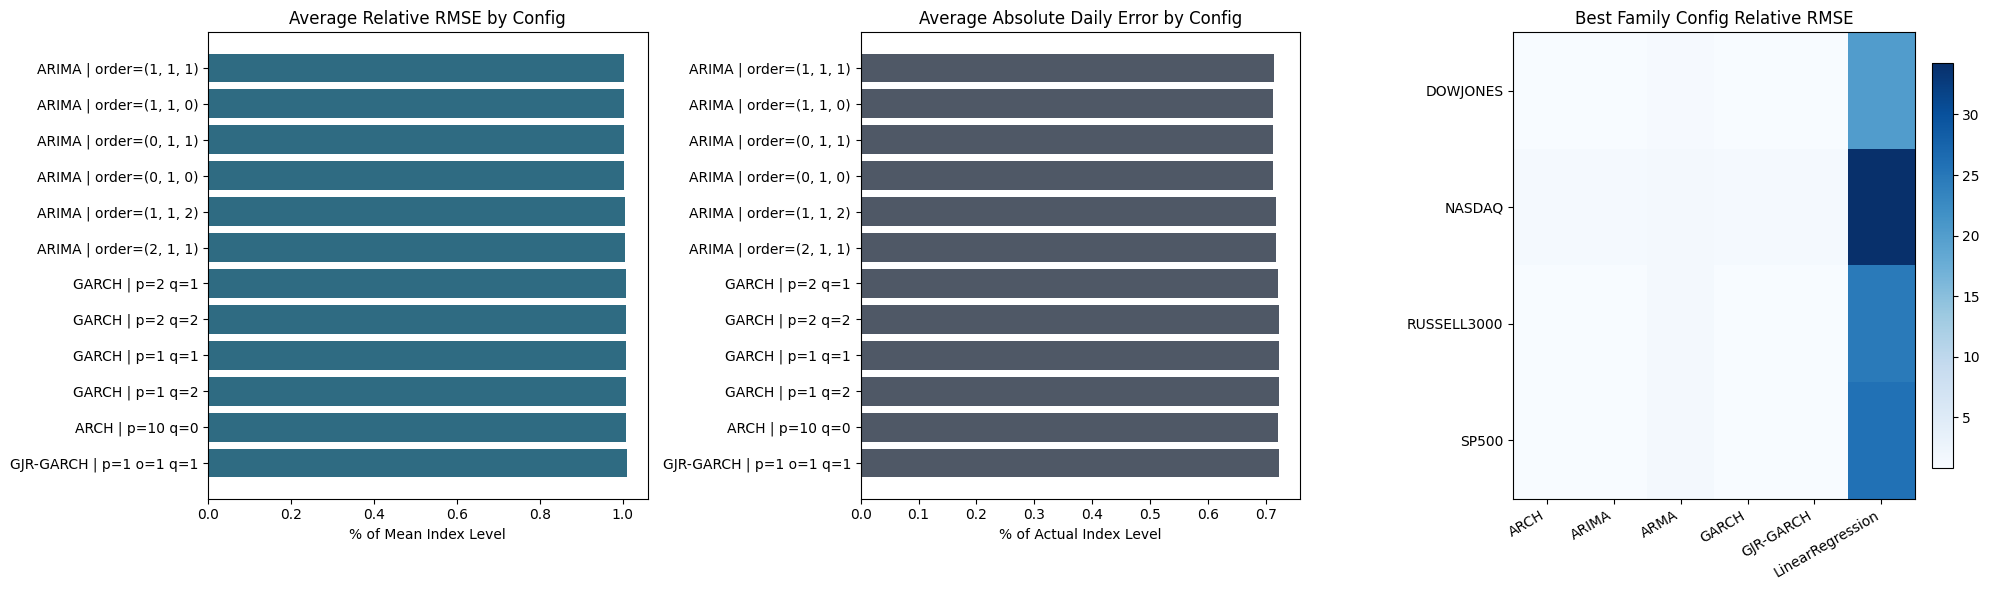

,benchmark_label,avg_eval_close_RMSE_pct,avg_eval_abs_error_pct_mean,avg_eval_close_MAE_pct,avg_fit_seconds
0,"ARIMA | order=(1, 1, 1)",1.002769,0.714455,0.708326,1.846739
1,"ARIMA | order=(1, 1, 0)",1.003410,0.712931,0.706863,1.702085
2,"ARIMA | order=(0, 1, 1)",1.003570,0.712844,0.706800,1.826392
3,"ARIMA | order=(0, 1, 0)",1.003771,0.712764,0.706728,1.675528
4,"ARIMA | order=(1, 1, 2)",1.004983,0.717476,0.711560,1.841716
5,"ARIMA | order=(2, 1, 1)",1.005714,0.717015,0.711154,1.872972
6,GARCH | p=2 q=1,1.008291,0.721710,0.715542,0.007367
7,GARCH | p=2 q=2,1.008397,0.721914,0.715739,0.011209
8,GARCH | p=1 q=1,1.008523,0.722356,0.716161,0.006139
9,GARCH | p=1 q=2,1.008596,0.722431,0.716237,0.009952


model,ARCH,ARIMA,ARMA,GARCH,GJR-GARCH,LinearRegression
index_key,,,,,,
DOWJONES,0.855815,0.856304,1.242709,0.855820,0.855320,20.102728
NASDAQ,1.267943,1.283880,1.573024,1.267060,1.268420,34.221691
RUSSELL3000,0.966484,0.963367,1.387120,0.965548,0.965908,24.667249
SP500,0.946782,0.954952,1.406200,0.945961,0.946112,25.802542


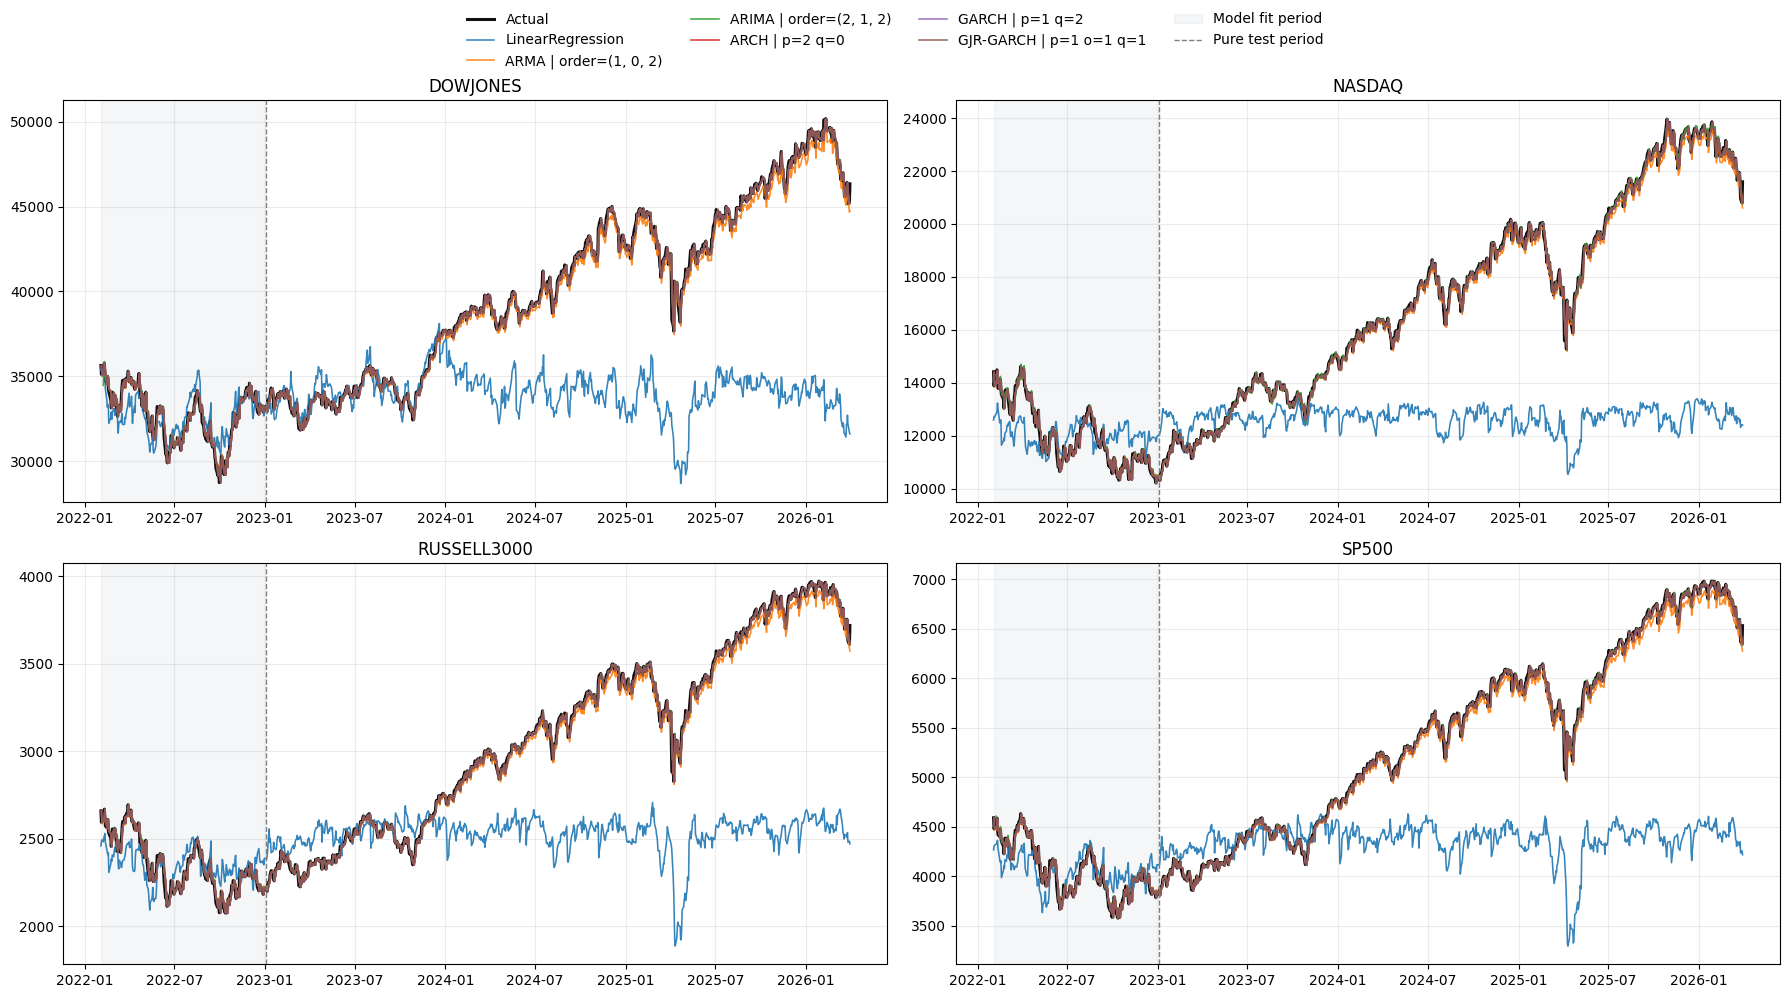

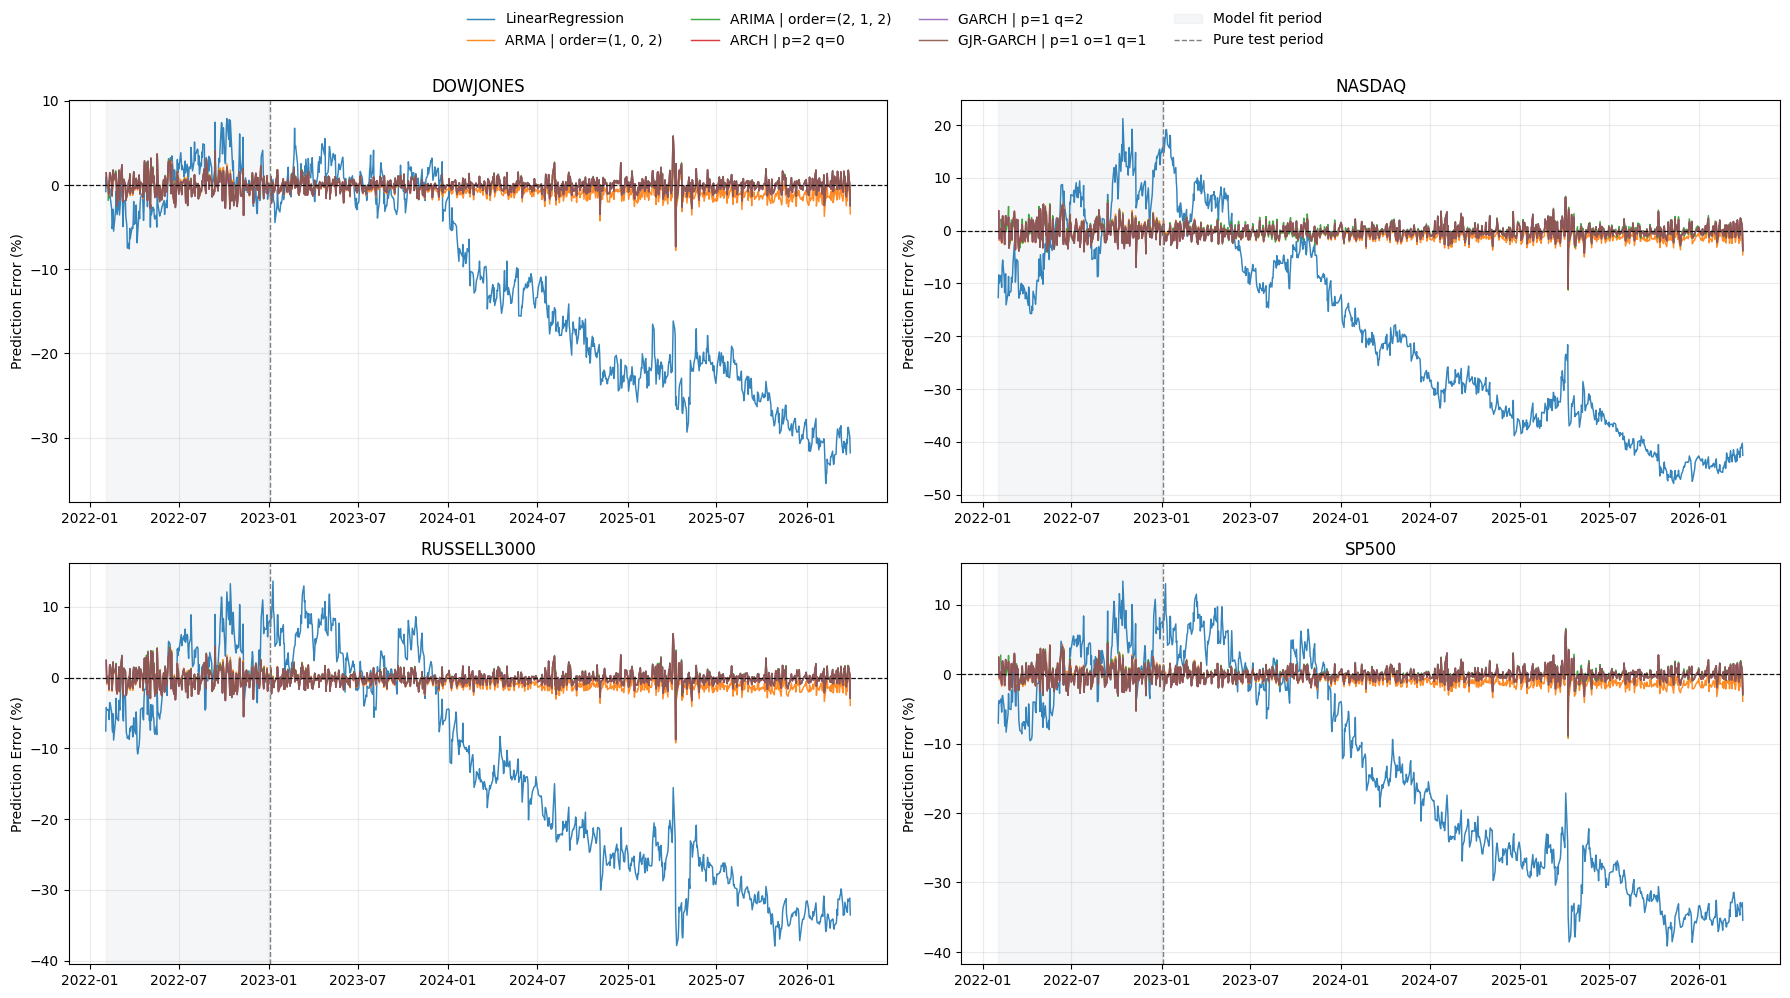

,index_key,benchmark_label,prediction_space,selection_metric,eval_close_RMSE,eval_close_RMSE_pct,eval_close_MAE,eval_close_MAE_pct,eval_abs_error_pct_mean,eval_error_pct_bias
0,DOWJONES,GJR-GARCH | p=1 o=1 q=1,level,415.166922,344.249132,0.855320,244.817220,0.608272,0.607224,-0.058037
1,DOWJONES,ARCH | p=2 q=0,level,415.154293,344.448096,0.855815,245.128909,0.609047,0.607982,-0.064854
2,DOWJONES,GARCH | p=1 q=2,level,415.154268,344.450083,0.855820,245.132212,0.609055,0.607990,-0.064918
3,DOWJONES,"ARIMA | order=(2, 1, 2)",level,413.631687,344.644894,0.856304,244.988900,0.608699,0.607861,-0.039001
4,DOWJONES,"ARMA | order=(1, 0, 2)",level,409.651051,500.165133,1.242709,393.387756,0.977410,0.944556,-0.725119
5,DOWJONES,LinearRegression,level,1050.266875,8090.940753,20.102728,6423.168598,15.958986,14.713735,-14.058262
6,NASDAQ,GARCH | p=1 q=2,level,244.136431,219.852162,1.267060,158.459789,0.913241,0.924677,-0.183392
7,NASDAQ,ARCH | p=1 q=0,level,244.134001,220.005394,1.267943,158.798231,0.915192,0.926718,-0.191364
8,NASDAQ,GJR-GARCH | p=1 o=1 q=1,level,244.133480,220.088077,1.268420,158.844343,0.915458,0.926959,-0.193561
9,NASDAQ,"ARIMA | order=(2, 1, 2)",level,238.938592,222.770675,1.283880,159.752621,0.920692,0.937326,-0.080649


[TIMER] build_summary_figures: 1.60s


In [5]:

with timed_step("build_summary_figures"):
    summary_figure_path = FIG_DIR / "01_model_overview.png"
    line_figure_path = FIG_DIR / "02_all_model_index_level_paths.png"
    error_figure_path = FIG_DIR / "03_all_model_error_pct_paths.png"
    if model_summary.empty or config_average_ranking.empty:
        print("No completed runs available for summary figures.")
    else:
        top_ranked = config_average_ranking.head(min(12, len(config_average_ranking))).copy()
        family_heatmap = best_configs.pivot(index="index_key", columns="model", values="eval_close_RMSE_pct").sort_index()

        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        axes[0].barh(top_ranked["benchmark_label"], top_ranked["avg_eval_close_RMSE_pct"], color="#2f6b82")
        axes[0].set_title("Average Relative RMSE by Config")
        axes[0].set_xlabel("% of Mean Index Level")
        axes[0].invert_yaxis()

        axes[1].barh(top_ranked["benchmark_label"], top_ranked["avg_eval_abs_error_pct_mean"], color="#4f5866")
        axes[1].set_title("Average Absolute Daily Error by Config")
        axes[1].set_xlabel("% of Actual Index Level")
        axes[1].invert_yaxis()

        im = axes[2].imshow(family_heatmap.to_numpy(dtype=float), aspect="auto", cmap="Blues")
        axes[2].set_title("Best Family Config Relative RMSE")
        axes[2].set_xticks(range(len(family_heatmap.columns)))
        axes[2].set_xticklabels(list(family_heatmap.columns), rotation=30, ha="right")
        axes[2].set_yticks(range(len(family_heatmap.index)))
        axes[2].set_yticklabels(list(family_heatmap.index))
        fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

        fig.tight_layout()
        fig.savefig(summary_figure_path, dpi=200, bbox_inches="tight")
        plt.show()
        display(top_ranked[["benchmark_label", "avg_eval_close_RMSE_pct", "avg_eval_abs_error_pct_mean", "avg_eval_close_MAE_pct", "avg_fit_seconds"]].round(6))
        display(family_heatmap.round(6))

        fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=False)
        axes = np.asarray(axes).reshape(-1)
        ordered_models = ["LinearRegression", "ARMA", "ARIMA", "ARCH", "GARCH", "GJR-GARCH"]
        for ax, (index_key, group) in zip(axes, model_summary.groupby("index_key", sort=True)):
            group = group.copy()
            group["model_rank"] = group["model"].map({name: i for i, name in enumerate(ordered_models)})
            group = group.sort_values(["model_rank", "eval_close_RMSE_pct", "eval_abs_error_pct_mean"]).reset_index(drop=True)

            base_actual_frame = None
            for _, row in group.iterrows():
                pred_frame = pd.read_csv(row["prediction_path"])
                pred_frame["test_target_date"] = pd.to_datetime(pred_frame["test_target_date"], errors="coerce")
                pred_frame = pred_frame.sort_values("test_target_date").reset_index(drop=True)
                pred_frame = add_error_columns(pred_frame)
                if PLOT_PREDICTION_SCOPE == "pure_test_only":
                    pred_frame = pred_frame.loc[pred_frame["analysis_partition"].eq("pure_test")].copy()
                elif PLOT_PREDICTION_SCOPE != "all_logged":
                    raise ValueError(PLOT_PREDICTION_SCOPE)

                if base_actual_frame is None:
                    base_actual_frame = pred_frame.copy()
                    ax.plot(
                        base_actual_frame["test_target_date"],
                        base_actual_frame["actual_close"],
                        label="Actual",
                        color="#111111",
                        linewidth=2.2,
                    )

                ax.plot(
                    pred_frame["test_target_date"],
                    pred_frame["predicted_close"],
                    label=row["benchmark_label"],
                    linewidth=1.15,
                    alpha=0.9,
                )

            if base_actual_frame is not None and PLOT_SHADE_PRE_TEST_PERIOD and PLOT_PREDICTION_SCOPE == "all_logged":
                fit_mask = base_actual_frame["analysis_partition"].eq("fit_period")
                pure_mask = base_actual_frame["analysis_partition"].eq("pure_test")
                if int(fit_mask.sum()) > 0:
                    fit_end = base_actual_frame.loc[fit_mask, "test_target_date"].max()
                    fit_start = base_actual_frame.loc[fit_mask, "test_target_date"].min()
                    ax.axvspan(fit_start, fit_end, color="#d9dde3", alpha=0.25, label=PRE_TEST_LABEL)
                if int(pure_mask.sum()) > 0:
                    pure_start = base_actual_frame.loc[pure_mask, "test_target_date"].min()
                    ax.axvline(pure_start, color="#808080", linestyle="--", linewidth=1.0, label=PURE_TEST_LABEL)

            ax.set_title(index_key)
            ax.grid(alpha=0.25)

        handles, labels = axes[0].get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        fig.legend(unique.values(), unique.keys(), loc="upper center", ncol=4, frameon=False)
        fig.tight_layout(rect=[0, 0, 1, 0.94])
        fig.savefig(line_figure_path, dpi=200, bbox_inches="tight")
        plt.show()

        fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=False)
        axes = np.asarray(axes).reshape(-1)
        for ax, (index_key, group) in zip(axes, model_summary.groupby("index_key", sort=True)):
            group = group.copy()
            group["model_rank"] = group["model"].map({name: i for i, name in enumerate(ordered_models)})
            group = group.sort_values(["model_rank", "eval_close_RMSE_pct", "eval_abs_error_pct_mean"]).reset_index(drop=True)

            for _, row in group.iterrows():
                pred_frame = pd.read_csv(row["prediction_path"])
                pred_frame["test_target_date"] = pd.to_datetime(pred_frame["test_target_date"], errors="coerce")
                pred_frame = pred_frame.sort_values("test_target_date").reset_index(drop=True)
                pred_frame = add_error_columns(pred_frame)
                if PLOT_PREDICTION_SCOPE == "pure_test_only":
                    pred_frame = pred_frame.loc[pred_frame["analysis_partition"].eq("pure_test")].copy()
                elif PLOT_PREDICTION_SCOPE != "all_logged":
                    raise ValueError(PLOT_PREDICTION_SCOPE)

                ax.plot(
                    pred_frame["test_target_date"],
                    pred_frame["error_pct"],
                    label=row["benchmark_label"],
                    linewidth=1.05,
                    alpha=0.9,
                )

            if PLOT_SHADE_PRE_TEST_PERIOD and PLOT_PREDICTION_SCOPE == "all_logged" and len(group) > 0:
                sample_frame = pd.read_csv(group.iloc[0]["prediction_path"])
                sample_frame["test_target_date"] = pd.to_datetime(sample_frame["test_target_date"], errors="coerce")
                sample_frame = sample_frame.sort_values("test_target_date").reset_index(drop=True)
                fit_mask = sample_frame["analysis_partition"].eq("fit_period")
                pure_mask = sample_frame["analysis_partition"].eq("pure_test")
                if int(fit_mask.sum()) > 0:
                    fit_end = sample_frame.loc[fit_mask, "test_target_date"].max()
                    fit_start = sample_frame.loc[fit_mask, "test_target_date"].min()
                    ax.axvspan(fit_start, fit_end, color="#d9dde3", alpha=0.25, label=PRE_TEST_LABEL)
                if int(pure_mask.sum()) > 0:
                    pure_start = sample_frame.loc[pure_mask, "test_target_date"].min()
                    ax.axvline(pure_start, color="#808080", linestyle="--", linewidth=1.0, label=PURE_TEST_LABEL)

            ax.axhline(0.0, color="#111111", linestyle="--", linewidth=0.9)
            ax.set_title(index_key)
            ax.set_ylabel("Prediction Error (%)")
            ax.grid(alpha=0.25)

        handles, labels = axes[0].get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        fig.legend(unique.values(), unique.keys(), loc="upper center", ncol=4, frameon=False)
        fig.tight_layout(rect=[0, 0, 1, 0.94])
        fig.savefig(error_figure_path, dpi=200, bbox_inches="tight")
        plt.show()
        display(
            model_summary[
                [
                    "index_key",
                    "benchmark_label",
                    "prediction_space",
                    "selection_metric",
                    "eval_close_RMSE",
                    "eval_close_RMSE_pct",
                    "eval_close_MAE",
                    "eval_close_MAE_pct",
                    "eval_abs_error_pct_mean",
                    "eval_error_pct_bias",
                ]
            ]
            .sort_values(["index_key", "eval_close_RMSE_pct", "eval_abs_error_pct_mean", "benchmark_label"])
            .reset_index(drop=True)
            .round(6)
        )